##### second_channel_various_cases.ipynb
### predicting the abundance history for various scenarios


##### Muhammed Saleem Cholayil (saleem.muhammed.c@gmail.com)
##### Heavily credited from philippe landry (pgjlandry@gmail.com) 02/2024

In [1]:
# import packages

import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import multivariate_normal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import corner
#from etc.rProcessUtils import rho_MW
#from etc.rProcessChemicalEvolution import rproc_evolution
from utils_nsbh import rho_MW
from utils_nsbh import rproc_evolution_nsbh
import utils_nsbh as ut_new
import importlib
from pp_utils import * 
import pickle

In [12]:
#importlib.reload(ut_new)
#from utils_nsbh import rho_MW, rproc_evolution_nsbh  # re-import updated versions

In [4]:
def calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile = 'abundance_history_data/BNS+eccNSBH.pkl',
            second_channel = 'nsbh',
            nsbh_rate_ejecta_file = 'uni', # or 'beta'
            rate_scale_factor = 1, 
            mej_scale_factor = 1,
            add_NSBH = True,
            NSBH_follow_SFR = False,
            show_abundance_plot = True,
            plot_label = 'BNS + ecc-NSBH',
            plot_color = 'gold'
        ):
    # second channel is by default NSBH and is named accordingly
    # when we consider cases like ecc-BNS, we pass different rates to the NSBH-named variables 
    
    # user input
    OBSPATH = '../etc/Battistini16_disk.csv' # path to disk star observations
    OBSPATH2 = '../etc/SAGA_MP.csv' # path to disk+halo star observations
    SOLARPATH = '../etc/Arnould07_solar_rprocess.dat' # path to solar r-process abundances

    
    FEH_MIN, FEH_MAX = (-3.,0.5)
    NFEH = int((FEH_MAX-FEH_MIN)/0.05) # Fe grid spacing for confidence intervals
    
    NSTP = 3 # number of subdivisions per time step in chemical evolution integration

    ##############
    # load BNS DTD parameter and rate-mej samples
    DTDPATH = '../etc/Zevin22_sgrb_dtd.dat' # path to delay time distribution parameter samples
    EJPATH = '../etc/mej_rate_lcehl_psr+gw+nicer.dat' # path to rate and ejecta samples

    alpha, tdmin, tdmax = np.loadtxt(DTDPATH, unpack=True, skiprows=1) # [], [yr], [yr]
    tdmin = tdmin/1e9 # convert to Gyr
    idxs = np.random.choice(range(len(alpha)),NSAMP,False) # jointly sample in alpha, tmin
    alphas = alpha[idxs]
    tdmins = tdmin[idxs]
    
    mej_dyn, mej_dsk, rate = np.loadtxt(EJPATH, unpack=True) # [Msun], [Msun], [MW^-1 Myr^-1]
    mej = mej_dyn + mej_dsk
    rate = rate*(1e9*rho_MW)/1e6 # convert to Gpc^-3 yr^-1
    idxs = np.random.choice(range(len(mej)),NSAMP,False) # jointly sample in rate, mej
    rates = rate[idxs]
    mejs = mej[idxs]
    
    samples = pd.DataFrame(np.column_stack((alphas,np.log10(tdmins*1e3),rates*mejs*1e6/(1e9*rho_MW)))) # [], [Myr], [MW^-1 Myr^-1]
    samples.columns = ['alpha','log10tmin','ratemej']
    
    alpha_nsbh, tdmin_nsbh, tdmax_nsbh = np.loadtxt(DTDPATH, unpack=True, skiprows=1) # [], [yr], [yr]
    tdmin_nsbh = tdmin_nsbh/1e9 # convert to Gyr
    # minimum delay time reduced by a factor of 10 for NSBH relative to BNS
    
    idxs_nsbh = np.random.choice(range(len(alpha_nsbh)),NSAMP,False) # jointly sample in alpha, tmin
    alphas_nsbh = alpha_nsbh[idxs_nsbh]
    tdmins_nsbh = tdmin_nsbh[idxs_nsbh]

    if second_channel == 'nsbh':
        if nsbh_rate_ejecta_file == 'uni':
            EJPATH_NSBH = "/home/muhammed.saleem/projects/rprocess/kaile_transfer/NSBHMejFraction/data/PDB_nsbh_uni.json"
        else:
            EJPATH_NSBH = "/home/muhammed.saleem/projects/rprocess/kaile_transfer/NSBHMejFraction/data/PDB_nsbh_beta.json"
        
        mej_nsbh = np.array(pd.read_json(EJPATH_NSBH)['weight_avg_mej'])
        rate_nsbh = np.array(pd.read_json(EJPATH_NSBH)['nsbh_rate'])
        

    if second_channel == 'bns':
        mej_dyn_nsbh, mej_dsk_nsbh, rate_nsbh = np.loadtxt(EJPATH, unpack=True) # [Msun], [Msun], [MW^-1 Myr^-1]
        mej_nsbh = mej_dyn_nsbh + mej_dsk_nsbh
        rate_nsbh = rate_nsbh*(1e9*rho_MW)/1e6 # convert to Gpc^-3 yr^-1
    
    rate_nsbh *= rate_scale_factor # scaling for eccentric rate
    mej_nsbh  *= mej_scale_factor
    
    idxs_nsbh = np.random.choice(range(len(mej_nsbh)),NSAMP,False) # jointly sample in rate, mej
    rates_nsbh = rate_nsbh[idxs_nsbh]
    mejs_nsbh  = mej_nsbh[idxs_nsbh]

    samples_nsbh = pd.DataFrame(np.column_stack((alphas_nsbh,np.log10(tdmins_nsbh*1e3),rates_nsbh*mejs_nsbh*1e6/(1e9*rho_MW)))) # [], [Myr], [MW^-1 Myr^-1]
    samples_nsbh.columns = ['alpha','log10tmin','ratemej']

    #####################################
    # load disk star observations and make gaussian likelihood model for each datapoint
    
    FeHs, EuFes, FeH_errs, EuFe_errs = np.loadtxt(OBSPATH, unpack=True, delimiter=',', skiprows=1)
    
    like_means = []
    like_stds = []
    
    for fe,eu,fe_err,eu_err in zip(FeHs, EuFes, FeH_errs, EuFe_errs):
    
        mean = np.array([fe,eu])
        std = np.array([[fe_err,0.],[0.,eu_err]])
        
        like_means += [mean]
        like_stds += [std]   
        
    like_funcs = [multivariate_normal(mean,std) for mean,std in zip(like_means,like_stds)]
    
    # load disk+halo star observations for plotting
    
    FeHs2, EuFes2, FeH_errs2, EuFe_errs2 = np.loadtxt(OBSPATH2, unpack=True, delimiter=',', skiprows=1)

    ##################################
    # compute predicted galactic r-process enrichment histories and their likelihood, given the stellar observations
    # 500 iterations max
    FeH_grid = np.linspace(FEH_MIN,FEH_MAX,NFEH)
    loglike, EuFe_pts = [], []
    
    for i,(alpha,tdmin,rate,mej, alpha_nsbh,tdmin_nsbh,rate_nsbh,mej_nsbh, ) in tqdm(enumerate(zip(alphas,tdmins,rates,mejs, alphas_nsbh,tdmins_nsbh,rates_nsbh,mejs_nsbh))):
        
        FeH_track, EuFe_track, rate_evs = rproc_evolution_nsbh(
                    R_NSNS_z0 = rate,
                    R_NSBH_z0 = rate_nsbh,
                    m_r_NS = mej,
                    m_r_NSBH = mej_nsbh,
                    b_NS = -alpha,
                    b_NSBH = alpha_nsbh, #( positive)
                    tmin_NS = tdmin,
                    tmin_NSBH = tdmin_nsbh,
                    Xcoll = 0,
                    f_NSgal=0.5,
                    f_NSBHgal=0.5,
                    nppdt=NSTP,
                    add_NSBH = True,
                    NSBH_follow_SFR=NSBH_follow_SFR)
    
        
        EuFe_of_FeH = interp1d(FeH_track,EuFe_track,bounds_error=False)
        EuFe_pts += [EuFe_of_FeH(FeH_grid)]
        
    EuFe_pts = np.array(EuFe_pts)
    
    # calculate abundance history confidence envelopes
    
    CLS = [0.68,0.9]
    md, qs = [], []
    
    for i in range(NFEH):
        
        qs += [wtquantile(EuFe_pts[:,i],[0.68,0.9])]
        md += [wtquantile(EuFe_pts[:,i],0.)]
        
    qs = np.array(qs)
    
    data = {"FeH_grid": FeH_grid,
            "qs": qs,
            "md": md,
            "color": plot_color,
            "label": plot_label,
           }
    
    with open(outfile, 'wb') as f:
        pickle.dump(data, f)

    if show_abundance_plot:
        plot_abundance_history ([data], show_observed=True)

                

## BNS + ecc-NSBH with SFR (beta-mej)

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid v

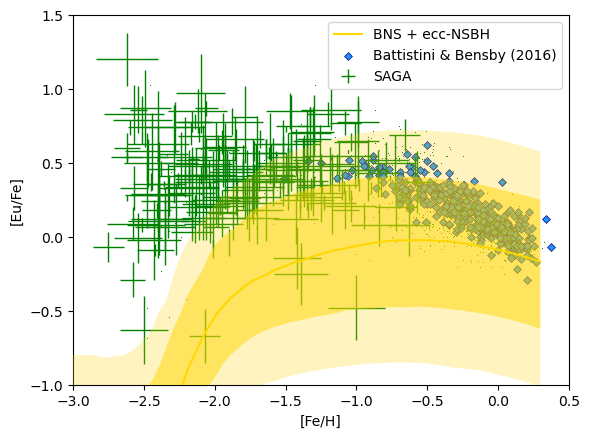

In [5]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+eccNSBH.pkl',
            second_channel      = 'nsbh',
            nsbh_rate_ejecta_file = 'beta', # or 'beta'
            rate_scale_factor   = 0.1, 
            mej_scale_factor    = 1,
            add_NSBH            = True,
            NSBH_follow_SFR     = True,
            show_abundance_plot = True,
            plot_label          = 'BNS + ecc-NSBH',
            plot_color          = 'gold'
        )

## BNS + ecc-NSBH with SFR (uni-mej)

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid v

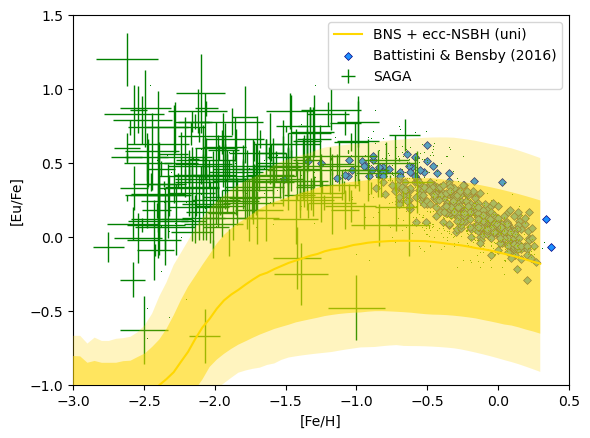

In [6]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+eccNSBH-uni.pkl',
            second_channel      = 'nsbh',
            nsbh_rate_ejecta_file = 'uni', # or 'beta'
            rate_scale_factor   = 0.1, 
            mej_scale_factor    = 1,
            add_NSBH            = True,
            NSBH_follow_SFR     = True,
            show_abundance_plot = True,
            plot_label          = 'BNS + ecc-NSBH (uni)',
            plot_color          = 'gold'
        )

## BNS + NSBH with SFR (uni-mej)

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid v

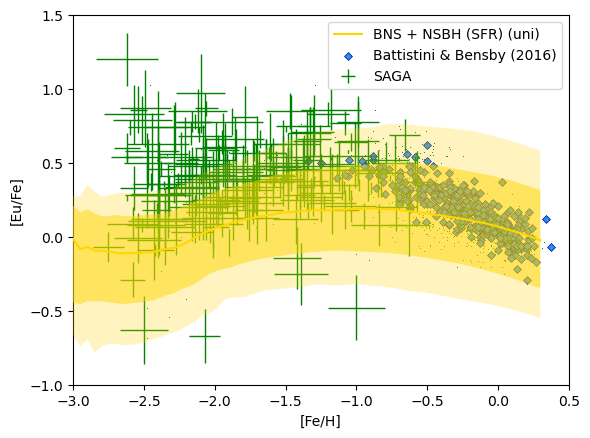

In [7]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+NSBH-with-SFR-uni.pkl',
            second_channel      = 'nsbh',
            nsbh_rate_ejecta_file = 'uni', # or 'beta'
            rate_scale_factor   = 1, 
            mej_scale_factor    = 1,
            add_NSBH            = True,
            NSBH_follow_SFR     = True,
            show_abundance_plot = True,
            plot_label          = 'BNS + NSBH (SFR) (uni)',
            plot_color          = 'gold'
        )

## BNS + NSBH with SFR (beta-mej)

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid v

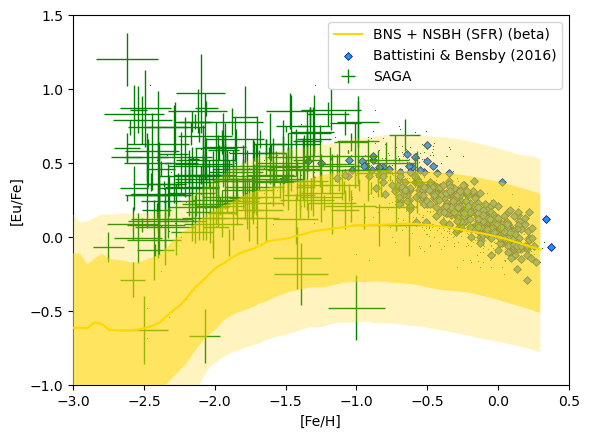

In [8]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+NSBH-with-SFR.pkl',
            second_channel      = 'nsbh',
            nsbh_rate_ejecta_file = 'beta', # or 'beta'
            rate_scale_factor   = 1, 
            mej_scale_factor    = 1,
            add_NSBH            = True,
            NSBH_follow_SFR     = True,
            show_abundance_plot = True,
            plot_label          = 'BNS + NSBH (SFR) (beta)',
            plot_color          = 'gold'
        )

## BNS + NSBH with BNS-DTD (uni-mej)

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: divide by zero encountered in power
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value 

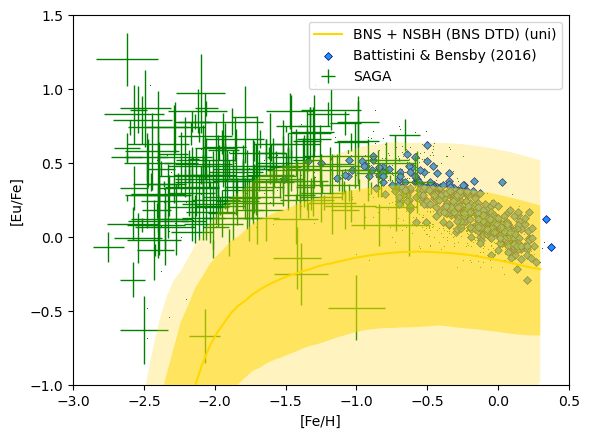

In [9]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+NSBH-with-BNS-DTD-uni.pkl',
            second_channel      = 'nsbh',
            nsbh_rate_ejecta_file = 'uni', # or 'beta'
            rate_scale_factor   = 1, 
            mej_scale_factor    = 1,
            add_NSBH            = True,
            NSBH_follow_SFR     = False,
            show_abundance_plot = True,
            plot_label          = 'BNS + NSBH (BNS DTD) (uni)',
            plot_color          = 'gold'
        )

## BNS + NSBH with BNS-DTD (beta-mej)

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: divide by zero encountered in power
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value 

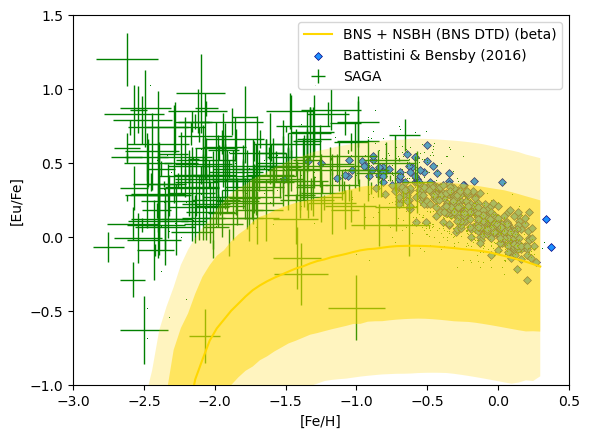

In [10]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+NSBH-with-BNS-DTD.pkl',
            second_channel      = 'nsbh',
            nsbh_rate_ejecta_file = 'beta', # or 'beta'
            rate_scale_factor   = 1, 
            mej_scale_factor    = 1,
            add_NSBH            = True,
            NSBH_follow_SFR     = False,
            show_abundance_plot = True,
            plot_label          = 'BNS + NSBH (BNS DTD) (beta)',
            plot_color          = 'gold'
        )

## BNS + ecc-BNS 

/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/.conda/envs/tbs-igwn-py39/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  warnings.warn(msg, RuntimeWarning)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in true_divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: divide by zero encountered in power
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value 

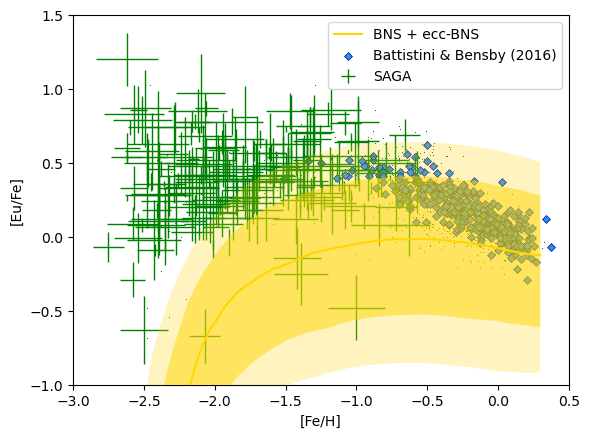

In [11]:
calculate_abundance_history (
            NSAMP = 500, # number of delay time distribution parameter samples to draw
            outfile             = 'abundance_history_data/BNS+eccBNS.pkl',
            second_channel      = 'bns',
            nsbh_rate_ejecta_file = 'uni', # or 'beta'
            rate_scale_factor   = 0.1, 
            mej_scale_factor    = 2,
            add_NSBH            = True,
            NSBH_follow_SFR     = False,
            show_abundance_plot = True,
            plot_label          = 'BNS + ecc-BNS',
            plot_color          = 'gold'
        )

# Overplotting with BNS-only curve

In [13]:
import glob
pkl_files = glob.glob('./abundance_history_data/*.pkl')
pkl_files

['./abundance_history_data/BNS+eccNSBH-uni.pkl',
 './abundance_history_data/BNS+NSBH-with-BNS-DTD.pkl',
 './abundance_history_data/BNS+NSBH-with-SFR-uni.pkl',
 './abundance_history_data/BNS.pkl',
 './abundance_history_data/BNS+NSBH-with-SFR.pkl',
 './abundance_history_data/BNS+eccBNS.pkl',
 './abundance_history_data/BNS+NSBH-with-BNS-DTD-uni.pkl',
 './abundance_history_data/BNS+eccNSBH.pkl']

In [15]:
with open('./abundance_history_data/BNS.pkl', 'rb') as f:
    data_bns = pickle.load(f)
data_bns['color'] = 'k'

with open('./abundance_history_data/BNS+NSBH-with-BNS-DTD.pkl', 'rb') as f:
    data_bns_nsbh_dtd_beta = pickle.load(f)
with open('./abundance_history_data/BNS+NSBH-with-BNS-DTD-uni.pkl', 'rb') as f:
    data_bns_nsbh_dtd_uni = pickle.load(f)


with open('./abundance_history_data/BNS+NSBH-with-SFR.pkl', 'rb') as f:
    data_bns_nsbh_sfr_beta = pickle.load(f)
with open('./abundance_history_data/BNS+NSBH-with-SFR-uni.pkl', 'rb') as f:
    data_bns_nsbh_sfr_uni = pickle.load(f)


with open('./abundance_history_data/BNS+eccBNS.pkl', 'rb') as f:
    data_bns_eccbns = pickle.load(f)

with open('./abundance_history_data/BNS+eccNSBH.pkl', 'rb') as f:
    data_bns_eccnsbh_beta = pickle.load(f)
with open('./abundance_history_data/BNS+eccNSBH-uni.pkl', 'rb') as f:
    data_bns_eccnsbh_uni = pickle.load(f)

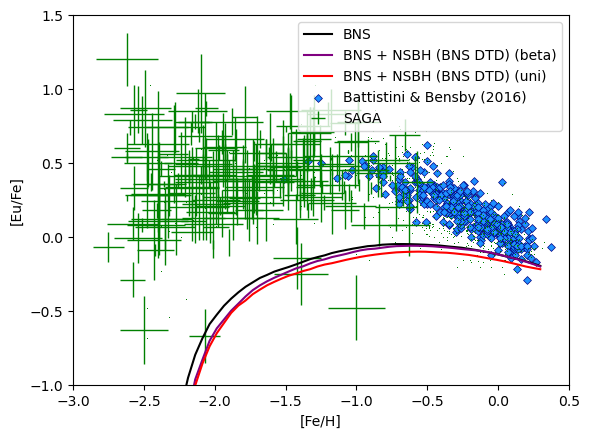

In [23]:
data_bns_nsbh_dtd_beta['color'] = 'purple' 
data_bns_nsbh_dtd_uni['color']  = 'red'
plot_abundance_history ([data_bns, data_bns_nsbh_dtd_beta, data_bns_nsbh_dtd_uni], 
                           show_observed=True, show_error_bar=False)    

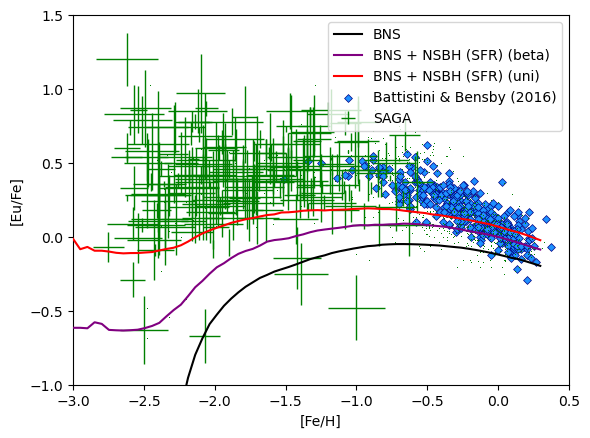

In [24]:
data_bns_nsbh_sfr_beta['color'] = 'purple' 
data_bns_nsbh_sfr_uni['color']  = 'red'
plot_abundance_history ([data_bns, data_bns_nsbh_sfr_beta, data_bns_nsbh_sfr_uni], 
                           show_observed=True, show_error_bar=False)    

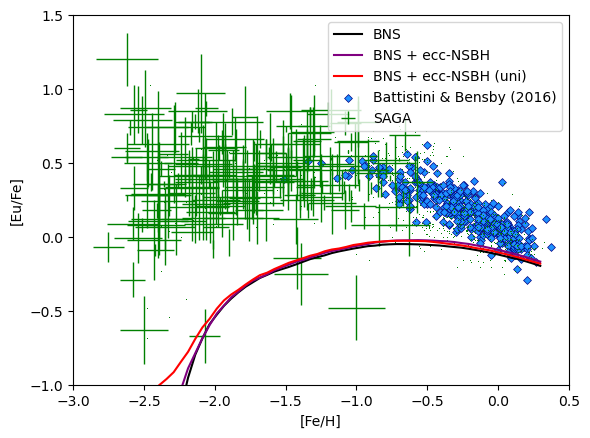

In [25]:
data_bns_eccnsbh_beta['color'] = 'purple' 
data_bns_eccnsbh_uni['color']  = 'red'
plot_abundance_history ([data_bns, data_bns_eccnsbh_beta, data_bns_eccnsbh_uni], 
                           show_observed=True, show_error_bar=False)    

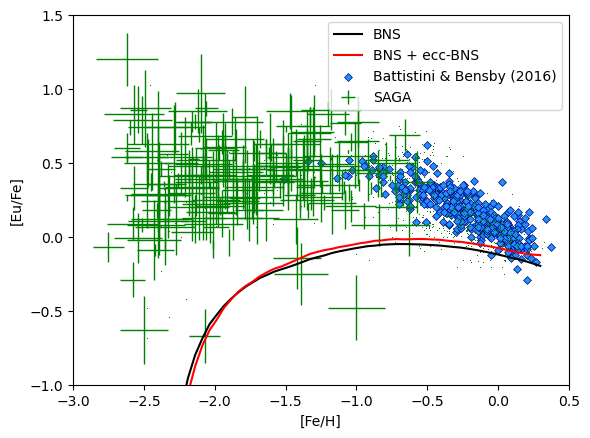

In [27]:
data_bns_eccbns['color'] = 'red' 
plot_abundance_history ([data_bns, data_bns_eccbns], 
                           show_observed=True, show_error_bar=False)    

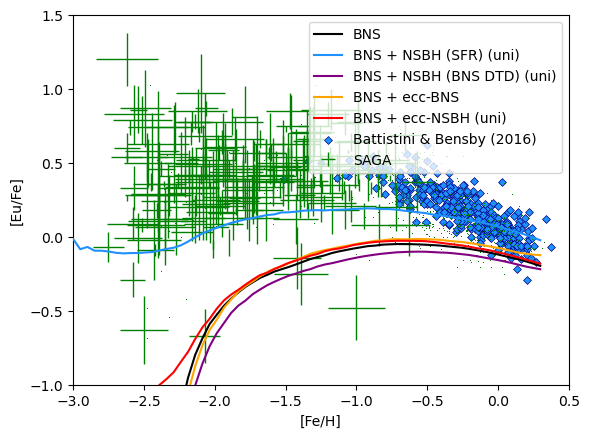

In [30]:
data_bns_eccbns['color'] = 'orange' 
data_bns_nsbh_sfr_uni['color'] = 'dodgerblue'
data_bns_nsbh_dtd_uni['color'] = 'purple'
data_bns_eccnsbh_uni['color']  = 'red'

plot_abundance_history ([data_bns, 
                         data_bns_nsbh_sfr_uni, 
                         data_bns_nsbh_dtd_uni,
                         data_bns_eccbns,
                         data_bns_eccnsbh_uni
                        ], 
                        show_observed=True, show_error_bar=False)    